Objective:
To classify images in the CIFAR10 dataset using convolutional neural networks.

Data:
CIFAR10 is a subset of the 80 million tiny images dataset. They were collected by Alex Krizhevsky, Vinod Nair, and Geoffrey Hinton. The dataset is available at CIFAR-10 and CIFAR-100 datasets (toronto.edu) and can also be loaded directly from TensorFlow using tf.keras.datasets.cifar10.load_data.

Problem Statement:
Image classification is an important part of computer vision systems. Equipped with a digital camera and a single board computer (such as a Raspberry Pi), smart technology can capture an image, determine what is in the image using a classification model, and then take an action based on that information. As a warmup exercise to develop such technology, consider that you are tasked to classify images from the CIFAR10 dataset. You are to build your own CNN model for this, both from scratch and from an existing model via transfer learning and fine tuning.


In [1]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow.keras as keras


# Data
1. Load CIFAR10 dataset into training and testing, features and labels numpy arrays using cifar10.load_data. Using markdown, list the 10 classes.

In [2]:

(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()


170500096/170498071 [==============================] - 3s 0us/step


In [3]:
# Print off shape
print("Training features shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test features shape:", x_test.shape)
print("Test labels shape:", y_test.shape)

Training features shape: (50000, 32, 32, 3)
Training labels shape: (50000, 1)
Test features shape: (10000, 32, 32, 3)
Test labels shape: (10000, 1)


CIFAR-10 Classes
|     | Class |
| -------- | ------- |
| 1 |  Airplane   |
| 2 |  Automobile    |
| 3 |  Bird   |
| 4 |  Cat   |
| 5 |  Deer    |
| 6 |  Dog   |
| 7 |  Frog   |
| 8 |  Horse    |
| 9 |  Ship   |
| 10 | Truck    |

2. Create a bar plot using seaborn.barplot of the number of elements in each category of the entire dataset. Use markdown to comment on how well balanced the dataset is.

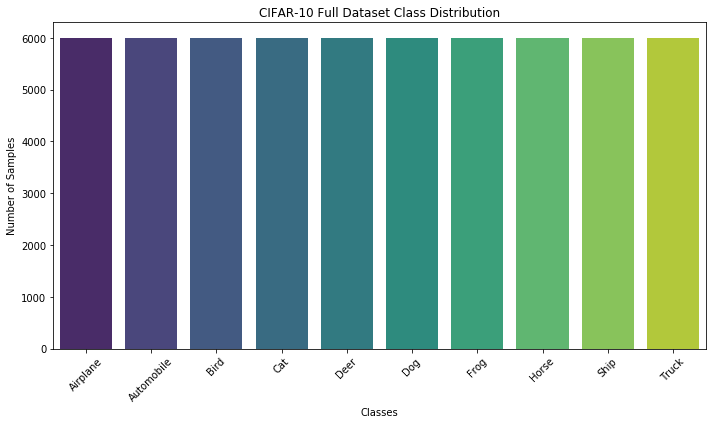

In [4]:
# Flatten and combine all labels
y_all = np.concatenate([y_train, y_test]).flatten()

# Class names
class_names = ['Airplane', 'Automobile', 'Bird', 'Cat', 'Deer',
               'Dog', 'Frog', 'Horse', 'Ship', 'Truck']

# Create countplot
plt.figure(figsize=(10, 6))
sns.countplot(x=y_all, palette='viridis')
plt.xticks(ticks=range(10), labels=class_names, rotation=45)
plt.title('CIFAR-10 Full Dataset Class Distribution')
plt.xlabel('Classes')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

Dataset is perfectly balanced

3. Use sklearn.model_selection.train_test_split to split the test set into test and validation sets choosing appropriate proportions. 

In [5]:
# split the test set into test and validation sets
x_val, x_test_new, y_val, y_test_new = train_test_split(
    x_test, y_test, 
    test_size=0.75, 
    random_state=42,
    stratify=y_test
)

print(f"Validation shape: {x_val.shape}")    
print(f"Test shape: {x_test_new.shape}")    

Validation shape: (2500, 32, 32, 3)
Test shape: (7500, 32, 32, 3)


4. Create train, test, and validation data generators using tensorflow.keras.preprocessing.image.ImageDataGenerator; each should scale the data by dividing by 255, and the training generator should also use data augmentation. 

In [6]:
# Rescale all by /255
train_datagen = ImageDataGenerator(
    rescale=1/255,
    rotation_range=15,      # Random rotation up to 15 degrees
    width_shift_range=0.1,  # Horizontal shift
    height_shift_range=0.1, # Vertical shift
    horizontal_flip=True,   # Random horizontal flips
    zoom_range=0.1          # Random zoom
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

# Batch that divides evenly
batch_size = 25

# Create generators using flow() for NumPy arrays
train_generator = train_datagen.flow(
    x_train, y_train,
    batch_size=batch_size,
    shuffle=True
)

val_generator = val_datagen.flow(
    x_val, y_val,
    batch_size=batch_size,
    shuffle=False
)

test_generator = test_datagen.flow(
    x_test_new, y_test_new,
    batch_size=batch_size,
    shuffle=False
)


# Modeling 
1. Use tf.keras.Sequential to create a convolutional neural network. Use at least two convolution layers and at least two pooling layers. Choose an activation function for each layer, and make sure the input and output dimensions are appropriate for the data. Print a summary of the model using tf.summary.

In [7]:
# Instantiate model with two convolustion layers and two pooling layers
model = tf.keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d (Conv2D)              (None, 30, 30, 32)        896       
_________________________________________________________________
max_pooling2d (MaxPooling2D) (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_1 (Conv2D)            (None, 13, 13, 32)        9248      
_________________________________________________________________
max_pooling2d_1 (MaxPooling2 (None, 6, 6, 32)          0         
_________________________________________________________________
flatten (Flatten)            (None, 1152)              0         
_________________________________________________________________
dense (Dense)                (None, 64)                73792     
_________________________________________________________________
dense_1 (Dense)              (None, 10)                6

2. Compile the model with a choice of optimizer, sparse_categorical_crossentropy for the loss function, and set the metrics argument equal to ['accuracy'].

In [8]:
# comile model with adam optimizer, sparse_categorical_crossentropy and accuracy for the metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

3. Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures other hyperparameters to improve upon the results.

In [9]:

# Train with exact steps (run after your generators)
steps_per_epoch = len(x_train) // batch_size  # 1562
val_steps = len(x_val) // batch_size          # 78

# Run the model with train and validation generator sets
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, 
    validation_data=val_generator,
    validation_steps=val_steps,
    verbose=1
)

# Capture accuracy and print results per epoch
train_acc = history.history['accuracy'][-1]
print(f"Baseline final training accuracy: {train_acc:.4f}")

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 2000 steps, validate for 100 steps
Epoch 1/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.6043 - accuracy: 0.4193 - val_loss: 1.3361 - val_accuracy: 0.5196
Epoch 2/10
2000/2000 [==============================] - 15s 8ms/step - loss: 1.3405 - accuracy: 0.5221 - val_loss: 1.1616 - val_accuracy: 0.6036
Epoch 3/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.2409 - accuracy: 0.5614 - val_loss: 1.1007 - val_accuracy: 0.6184
Epoch 4/10
2000/2000 [==============================] - 12s 6ms/step - loss: 1.1825 - accuracy: 0.5821 - val_loss: 1.0602 - val_accuracy: 0.6288
Epoch 5/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.1374 - accuracy: 0.6025 - val_loss: 1.0095 - val_accuracy: 0.6480
Epoch 6/10
2000/2000 [==============================] - 12s 6ms/step - loss: 1.1078 - accuracy: 0.6086 - val_loss: 1.0236 - val_accuracy: 0.6484
Epoch 7/10
2000/2000 [=============

### Hyper Parameter Testing

In [75]:
# Instantiate model with two convolustion layers and two pooling layers
model = tf.keras.Sequential([
    layers.Conv2D(32, 3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_29"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_68 (Conv2D)           (None, 30, 30, 32)        896       
_________________________________________________________________
max_pooling2d_68 (MaxPooling (None, 15, 15, 32)        0         
_________________________________________________________________
conv2d_69 (Conv2D)           (None, 13, 13, 64)        18496     
_________________________________________________________________
max_pooling2d_69 (MaxPooling (None, 6, 6, 64)          0         
_________________________________________________________________
flatten_29 (Flatten)         (None, 2304)              0         
_________________________________________________________________
dense_58 (Dense)             (None, 128)               295040    
_________________________________________________________________
dense_59 (Dense)             (None, 10)              

In [76]:
# comile model with adam optimizer, sparse_categorical_crossentropy and accuracy for the metric
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [77]:

# Train with exact steps (run after your generators)
steps_per_epoch = len(x_train) // batch_size  # 1562
val_steps = len(x_val) // batch_size          # 78

# Run the model with train and validation generator sets
history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=10, 
    validation_data=val_generator,
    validation_steps=val_steps,
    verbose=1
)

# Capture accuracy and print results per epoch
train_acc = history.history['accuracy'][-1]
print(f"Baseline final training accuracy: {train_acc:.4f}")

  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 2000 steps, validate for 100 steps
Epoch 1/10
2000/2000 [==============================] - 15s 7ms/step - loss: 1.5269 - accuracy: 0.4483 - val_loss: 1.1441 - val_accuracy: 0.5892
Epoch 2/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.2372 - accuracy: 0.5639 - val_loss: 1.0605 - val_accuracy: 0.6204
Epoch 3/10
2000/2000 [==============================] - 14s 7ms/step - loss: 1.1300 - accuracy: 0.6006 - val_loss: 0.9930 - val_accuracy: 0.6596
Epoch 4/10
2000/2000 [==============================] - 13s 6ms/step - loss: 1.0651 - accuracy: 0.6254 - val_loss: 0.9665 - val_accuracy: 0.6784
Epoch 5/10
2000/2000 [==============================] - 13s 6ms/step - loss: 1.0192 - accuracy: 0.6379 - val_loss: 0.9052 - val_accuracy: 0.6776
Epoch 6/10
2000/2000 [==============================] - 13s 6ms/step - loss: 0.9891 - accuracy: 0.6547 - val_loss: 0.8843 - val_accuracy: 0.6988
Epoch 7/10
2000/2000 [=============

Through extensive testing 0.726 was the lowest val_accuracy achievable

4. Start a new model by loading one of the models from tensorflow.keras.applications along with the pretrained weights; don't include the top layer. Check if your model comes with preprocess_input function and be sure to use that properly with your data before training. Describe the model you chose using markdown and explain why you think it will work well for this use case.

We chose MobileNetV2 from tensorflow.keras.applications, a lightweight pretrained model ideal for CIFAR-10 transfer learning without heavy computation.

MobileNetV2 is pretrained on ImageNet (1.4M images, 1000 classes) and excels on small RGB images like CIFAR-10's 32x32x3 via efficient depthwise separable convolutions.

| Feature    | Details                                                                                                                                                                       |
| ---------- | ----------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| Base       | MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))                                                                                    |
| Params     | ~2.2M trainable (after top); total ~3.5M tensorflow​                                                                                                                          |
| Layers     | 155 conv/inverted residual blocks + GlobalAvgPool2D                                                                                                                           |
| Preprocess | tf.keras.applications.mobilenet_v2.preprocess_input scales/normalizes to ImageNet stats (mean subtraction) github​                                                            |
| Why Chosen | Efficient (fast on CPU/GPU), strong low-level features (edges/textures) transfer well to CIFAR-10 objects |

In [10]:
import tensorflow.keras.applications as apps
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# New generators with MobileNetV2 preprocess
train_datagen_mob = ImageDataGenerator(
    preprocessing_function=preprocess_input,  # ImageNet stats
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)

# New generators for the uploaded model
val_datagen_mob = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen_mob = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator_mob = train_datagen_mob.flow(x_train, y_train, batch_size=batch_size, shuffle=True)
val_generator_mob = val_datagen_mob.flow(x_val, y_val, batch_size=batch_size, shuffle=False)
test_generator_mob = test_datagen_mob.flow(x_test_new, y_test_new, batch_size=batch_size, shuffle=False)


In [11]:
# Instantiate MobileNetV2 and make it untrainable 
base_model = apps.MobileNetV2(weights='imagenet', include_top=False, input_shape=(32,32,3))
base_model.trainable = False


c:\Users\Parker\anaconda3\envs\NN\lib\site-packages\keras_applications\mobilenet_v2.py:294: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  warnings.warn('`input_shape` is undefined or non-square, '


9412608/9406464 [==============================] - 0s 0us/step


5. Add on a new top layer with appropriate hyperparameter choices. Choose a number of layers to freeze. Print a summary of the model.

In [12]:
# After the existing model_mob definition and before the second .compile()

# Enhanced top layers with BatchNorm and additional Dense for better performance
model_mob = tf.keras.Sequential([
    base_model,
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

# Choose to freeze first 80% of layers 
num_layers = len(base_model.layers)
freeze_until_layer = int(0.8 * num_layers)
for layer in base_model.layers[:freeze_until_layer]:
    layer.trainable = False

# Print model summary
model_mob.summary()


Model: "sequential_1"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
mobilenetv2_1.00_224 (Model) (None, 1, 1, 1280)        2257984   
_________________________________________________________________
flatten_1 (Flatten)          (None, 1280)              0         
_________________________________________________________________
dense_2 (Dense)              (None, 128)               163968    
_________________________________________________________________
dense_3 (Dense)              (None, 10)                1290      
Total params: 2,423,242
Trainable params: 165,258
Non-trainable params: 2,257,984
_________________________________________________________________


6. Compile the model with a choice of optimizer and loss function, and the set the metrics argument equal to ['accuracy'].

In [13]:

# Re-compile with lower learning rate suitable for fine-tuning
model_mob.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print(f"Frozen first {freeze_until_layer} layers out of {num_layers} in base model.")



Frozen first 124 layers out of 155 in base model.


7. Train the model using the train and validation data generators; record the training accuracy. Experiment with different architectures, different numbers of frozen layers, and other hyperparameters to improve upon the results.

In [14]:
# Train the enhanced model_mob (with 80% frozen layers, improved top) using the mobile generators
steps_per_epoch = len(x_train) // batch_size  # 50000 // 32 = 1562
val_steps = len(x_val) // batch_size          # ~2500 // 32 ≈ 78

print("Training enhanced model_mob...")
history_enhanced = model_mob.fit(
    train_generator_mob,
    steps_per_epoch=steps_per_epoch,
    epochs=10,  # More epochs to leverage improvements
    validation_data=val_generator_mob,
    validation_steps=val_steps,
    verbose=1
)

# Record final training accuracy
train_acc_enhanced = history_enhanced.history['accuracy'][-1]
val_acc_enhanced = history_enhanced.history['val_accuracy'][-1]
print(f"Final training accuracy: {train_acc_enhanced:.4f}")
print(f"Final validation accuracy: {val_acc_enhanced:.4f}")


Training enhanced model_mob...
  ...
    to  
  ['...']
  ...
    to  
  ['...']
Train for 2000 steps, validate for 100 steps
Epoch 1/10
2000/2000 [==============================] - 31s 15ms/step - loss: 2.2056 - accuracy: 0.2137 - val_loss: 2.3049 - val_accuracy: 0.0776
Epoch 2/10
2000/2000 [==============================] - 30s 15ms/step - loss: 1.9835 - accuracy: 0.2939 - val_loss: 2.3034 - val_accuracy: 0.0776
Epoch 3/10
2000/2000 [==============================] - 33s 17ms/step - loss: 1.9173 - accuracy: 0.3187 - val_loss: 2.3030 - val_accuracy: 0.0824
Epoch 4/10
2000/2000 [==============================] - 33s 16ms/step - loss: 1.8931 - accuracy: 0.3305 - val_loss: 2.3046 - val_accuracy: 0.0856
Epoch 5/10
2000/2000 [==============================] - 35s 17ms/step - loss: 1.8748 - accuracy: 0.3346 - val_loss: 2.3072 - val_accuracy: 0.0848
Epoch 6/10
2000/2000 [==============================] - 35s 17ms/step - loss: 1.8548 - accuracy: 0.3412 - val_loss: 2.3082 - val_accuracy: 0.093

# Conclusion
1. Find the training and validation accuracies, and validation confusion matrix for both the custom CNN and transfer learning models. Present the results for both neatly. Use markdown to compare them and select the best model.

Custom CNN Results:
Training Accuracy: 0.6363
Validation Accuracy: 0.6548

Custom CNN Validation Confusion Matrix:
[[202  10   4   1   1   0   4   9  10   9]
 [  3 231   1   0   0   0   1   0   5   9]
 [ 26  11 102  10  31  15  31  13   7   4]
 [  5  20   9  89  21  25  56  13   3   9]
 [ 10   3  12  11 139   4  41  24   4   2]
 [  3   9   5  45  13 120  19  23   7   6]
 [  3   2   6   6   6   2 216   2   5   2]
 [  6   5   9   8  14   6   4 186   2  10]
 [ 27  14   0   2   0   0   1   0 199   7]
 [  6  76   0   2   1   1   3   2   6 153]]
Row sums (true class counts): [250 250 250 250 250 250 250 250 250 250]

Transfer Learning Results:
Training Accuracy: 0.3555
Validation Accuracy: 0.0968

MobileNetV2 Validation Confusion Matrix:
[[ 91   3  41   3  63   5   6   5  32   1]
 [182   0  29   1  21   0   0   0  17   0]
 [114   0  49   6  55   3   2   2  16   3]
 [154   1  31   8  34   1   1   0  20   0]
 [ 78   0  68   3  74   0   1   2  22   2]
 [168   0  27   6  23   1   3   0  20   2]


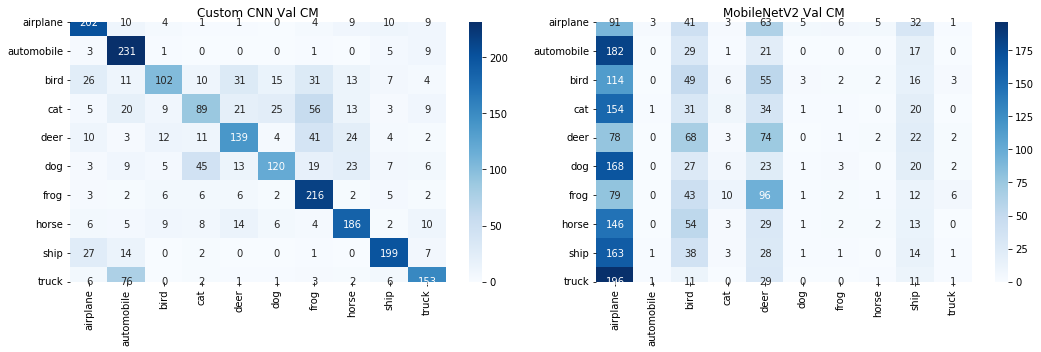

In [15]:
from sklearn.metrics import confusion_matrix


# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# For Custom CNN
print("Custom CNN Results:")
custom_train_acc = history.history['accuracy'][-1]
custom_val_acc = history.history['val_accuracy'][-1]
print(f"Training Accuracy: {custom_train_acc:.4f}")
print(f"Validation Accuracy: {custom_val_acc:.4f}")

val_generator.reset()
y_val_pred_custom = model.predict(val_generator, steps=val_steps, verbose=0)
y_val_pred_classes_custom = np.argmax(y_val_pred_custom, axis=1)

# UNNORMALIZED confusion matrix (raw counts)
cm_custom = confusion_matrix(y_val[:len(y_val_pred_classes_custom)], y_val_pred_classes_custom)
print("\nCustom CNN Validation Confusion Matrix:")
print(cm_custom)
print("Row sums (true class counts):", cm_custom.sum(axis=1))

# For Transfer Learning MobileNetV2
print("\nTransfer Learning Results:")
mob_train_acc = history_enhanced.history['accuracy'][-1]
mob_val_acc = history_enhanced.history['val_accuracy'][-1]
print(f"Training Accuracy: {mob_train_acc:.4f}")
print(f"Validation Accuracy: {mob_val_acc:.4f}")

val_generator_mob.reset()
y_val_pred_mob = model_mob.predict(val_generator_mob, steps=val_steps, verbose=0)
y_val_pred_classes_mob = np.argmax(y_val_pred_mob, axis=1)

# UNNORMALIZED confusion matrix
cm_mob = confusion_matrix(y_val[:len(y_val_pred_classes_mob)], y_val_pred_classes_mob)
print("\nMobileNetV2 Validation Confusion Matrix:")
print(cm_mob)
print("Row sums (true class counts):", cm_mob.sum(axis=1))

# Plot UNNORMALIZED heatmaps
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap(cm_custom, annot=True, fmt='d', ax=axes[0], cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
axes[0].set_title('Custom CNN Val CM')
sns.heatmap(cm_mob, annot=True, fmt='d', ax=axes[1], cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
axes[1].set_title('MobileNetV2 Val CM')
plt.tight_layout()
plt.show()

2. Find the testing accuracy and confusion matrix of only the best model.

3. Use the model to make predictions on at least three other images from one of the 10 classes.

4. Use markdown to comment on how well the model works to make predictions for this use case.